In [30]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import random
import math
import statsmodels

In [65]:
# Load your dataset (replace 'your_dataset.csv' with the actual file name)
df = pd.read_csv('winequality.csv')
df = df.dropna()
df = df.head(100)
top = ['residual sugar', 'chlorides', 'total sulfur dioxide', 'density', 'alcohol', 'fixed acidity', 'volatile acidity', 'citric acid', 'free sulfur dioxide', 'pH', 'sulphates']
variable1_name = top[3]
variable2_name = top[4]
variable3_name = 'free sulfur dioxide'

print(variable2_name, "-",variable3_name)

alcohol - free sulfur dioxide


In [45]:
#Task 1 part one mean
print(variable1_name)

oneORtwo = int(input("One tailed or two Tailed : "))

#assumed = round(sum(df[variable1_name]) / len(df[variable1_name]))
assumed = 0.9
print("Assumed value for the praportion : ", assumed)

alpha = 0.05
p_cap = len(df[df[variable1_name] > assumed])/100
p = 0.5
q = 1 - p
z_static = (p_cap - p)/math.sqrt(p*q/100)
print(f'P cap : {p_cap}')
print(f'THe Z-Critical : {stats.norm.ppf(1 - alpha / 2)}')
print(f'The Z-Static : {z_static:.3f}')

p_value_prop = stats.norm.cdf(z_static) if oneORtwo == 1 else stats.norm.cdf(z_static) * 2
print(f'P-value : {round(p_value_prop,3)}')

if p_value_prop < alpha:
    print("Reject the null hypothesis for the proportion. There is significant evidence that the proportion is different from your guess.")
else:
    print("Fail to reject the null hypothesis for the proportion. There is not enough evidence to suggest a difference in the proportion.")

density
One tailed or two Tailed : 1
Assumed value for the praportion :  0.9
P cap : 1.0
THe Z-Critical : 1.959963984540054
The Z-Static : 10.000
P-value : 1.0
Fail to reject the null hypothesis for the proportion. There is not enough evidence to suggest a difference in the proportion.


In [44]:
# Claim: Make an initial guess about the mean
print(variable1_name)

oneORtwo = int(input("One tailed or two Tailed : "))

#assumed = sum(df[variable1_name]) / len(df[variable1_name])
assumed = 0.9
print(assumed)

# Hypothesis test
print("Items", list(df[variable1_name]))

t_stat, p_value = stats.ttest_1samp(df[variable1_name], assumed)
p_value = p_value / 2 if oneORtwo == 1 else p_value
print(f'The T-Static : {t_stat:.3f}')
print(f'P-value : {p_value}')

# Confidence Interval
confidence_interval = stats.t.interval(0.95, len(df[variable1_name])-1, loc=np.mean(df[variable1_name]), scale=stats.sem(df[variable1_name]))

# Interpretation of results
if p_value < 0.05:
    print("Reject the null hypothesis. There is significant evidence that the mean is different from your guess.")
else:
    print("Fail to reject the null hypothesis. There is not enough evidence to suggest a difference in the mean.")

print("Confidence Interval for the mean:", confidence_interval)
print('\n\n')

density
One tailed or two Tailed : 1
0.9
Items [1.001, 0.994, 0.9951, 0.9956, 0.9956, 0.9951, 0.9949, 1.001, 0.994, 0.9938, 0.9908, 0.9947, 0.992, 0.9912, 1.0002, 0.9914, 0.9928, 0.9917, 0.9955, 0.9892, 0.9912, 0.993, 0.9937, 0.9951, 0.9955, 0.993, 0.9961, 0.9914, 0.9906, 0.9974, 0.9934, 0.992, 0.9962, 0.9905, 0.9934, 0.9906, 0.9999, 0.9999, 0.9937, 0.9937, 0.9954, 0.9934, 0.9934, 0.9931, 0.994, 0.9939, 0.9954, 0.995, 0.9917, 0.9914, 0.991, 0.9911, 0.9908, 0.9962, 0.9972, 0.9931, 0.9926, 0.9951, 0.9972, 0.991, 0.9931, 0.9927, 0.9934, 0.9903, 0.992, 0.9926, 0.9962, 0.9956, 0.9958, 0.9964, 0.9941, 0.9926, 0.9962, 0.9898, 0.9912, 0.9961, 0.9949, 0.9929, 0.9985, 0.9946, 0.9966, 0.9974, 0.9975, 0.9972, 0.9974, 0.9975, 0.9974, 0.9957, 0.99, 0.9899, 0.9916, 0.9969, 0.9979, 0.9913, 0.9979, 0.9975, 0.9962, 0.997, 1.0, 0.9975]
The T-Static : 340.582
P-value : 4.7623287689317306e-154
Reject the null hypothesis. There is significant evidence that the mean is different from your guess.
Confidence I

In [34]:
# means for variable 1 and 2
print(variable1_name, np.array(df[variable1_name]).mean())
print(variable2_name, np.array(df[variable2_name]).mean())

density 0.9944130000000001
alcohol 10.087


In [35]:
import numpy as np
from scipy.stats import t, ttest_ind

A = np.array(df[variable1_name]) # Random data for variable A
B = np.array(df[variable2_name]) # Random data for variable B

# Hypothesis Test for Means
t_stat, p_value_means = ttest_ind(A, B)
p_value_means = round(p_value_means, 3)
alpha = 0.05

# Confidence Interval for Means
dof_means = len(A) + len(B) - 2
t_critical_means = t.ppf(1-alpha/2, dof_means)

mean_diff = np.mean(A) - np.mean(B)
std_diff_means = np.sqrt((np.var(A) / len(A)) + (np.var(B) / len(B)))
margin_of_error_means = t_critical_means * std_diff_means
confidence_interval_means = (mean_diff - margin_of_error_means, mean_diff + margin_of_error_means)

# Hypothesis Test for Standard Deviations
F_stat = np.var(A, ddof=1) / np.var(B, ddof=1)
p_value_sd = 2 * min(t.cdf(F_stat, len(A) - 1, len(B) - 1), 1 - t.cdf(F_stat, len(A) - 1, len(B) - 1))
p_value_sd = round(p_value_sd, 3)

# Confidence Interval for Standard Deviations
dof_sd_A = len(A) - 1
dof_sd_B = len(B) - 1
F_critical_lower = t.ppf(0.975, dof_sd_B, dof_sd_A)
F_critical_upper = t.ppf(0.025, dof_sd_B, dof_sd_A)

ci_sd_A = np.var(A) / (F_critical_lower / F_stat)
ci_sd_B = np.var(A) / (F_critical_upper / F_stat)
confidence_interval_sd = (np.sqrt(ci_sd_A), np.sqrt(ci_sd_B))

# Print results for Means
print('Results for Means:')
print(f'Two-sample t-test:\n t-statistic = {t_stat}\n p-value = {p_value_means}\n')
print(f'Confidence Interval for the difference between means: {confidence_interval_means}\n')

# Interpretation for Means
if p_value_means < 0.05:
    print('Reject the null hypothesis. There is a significant difference between the means.')
else:
    print('Fail to reject the null hypothesis. There is no significant difference between the means.')

print("\n=====================================================================================")

# Print results for Standard Deviations
print('\nResults for Standard Deviations:')
print(f'F-statistic = {F_stat}\n p-value = {p_value_sd}\n')
print(f'Confidence Interval for the ratio of standard deviations: {confidence_interval_sd}\n')

# Interpretation for Standard Deviations
if p_value_sd < 0.05:
    print('Reject the null hypothesis. There is a significant difference between the standard deviations.')
else:
    print('Fail to reject the null hypothesis. There is no significant difference between the standard deviations.')


Results for Means:
Two-sample t-test:
 t-statistic = -81.76252410939817
 p-value = 0.0

Confidence Interval for the difference between means: (-9.31079040935732, -8.87438359064268)

Reject the null hypothesis. There is a significant difference between the means.


Results for Standard Deviations:
F-statistic = 6.213786141166061e-06
 p-value = 0.0

Confidence Interval for the ratio of standard deviations: (6.841935473007475e-07, 6.980467805373902e-07)

Reject the null hypothesis. There is a significant difference between the standard deviations.


In [36]:
# means for variable 1, 2 and 3
print(variable1_name, np.array(df[variable1_name]).mean())
print(variable2_name, np.array(df[variable2_name]).mean())
print(variable3_name, np.array(df[variable3_name]).mean())

density 0.9944130000000001
alcohol 10.087
free sulfur dioxide 36.365


In [47]:
alpha=0.05

first = df[variable1_name]
second = df[variable2_name]
third = df[variable3_name]

corr_first_second, _ = stats.pearsonr(first, second)
corr_first_third, _ = stats.pearsonr(first, third)

# Hypothesis testing
# Null hypothesis: There is no correlation (correlation coefficient = 0)
# Alternative hypothesis: There is a significant correlation (correlation coefficient ≠ 0)
t_stat_first_second, p_value_first_second = stats.pearsonr(first, second)
t_stat_first_third, p_value_first_third = stats.pearsonr(first, third)

# Confidence intervals
ci_first_second = np.percentile(np.arctanh(np.corrcoef(first, second)[0, 1]) * np.ones(100), [2.5, 97.5])
ci_first_third = np.percentile(np.arctanh(np.corrcoef(first, third)[0, 1]) * np.ones(100), [2.5, 97.5])

# Print results
print(f"Correlation between {variable1_name} and {variable2_name}: {round(corr_first_second), 4}")
print(f"Correlation between {variable1_name} and {variable3_name}: {round(corr_first_third, 4)}")

print("\nHypothesis Testing:")
print(f"P-value for {variable1_name} and {variable2_name}: {round(p_value_first_second,4)}")
print(f"P-value for {variable1_name} and {variable3_name}: {round(p_value_first_third, 4)}")

print("\nConfidence Intervals:")
print(f"95% CI for {variable1_name} and {variable2_name}: {np.tanh(ci_first_second)}")
print(f"95% CI for {variable1_name} and {variable3_name}: {np.tanh(ci_first_third)}")

# Interpretation
if p_value_first_second < alpha:
    print(f"\nReject the null hypothesis for {variable1_name} and {variable2_name}. There is a significant correlation.")
else:
    print(f"\nFail to reject the null hypothesis for {variable1_name} and {variable2_name}. There is no significant correlation.")

if p_value_first_third < alpha:
    print(f"Reject the null hypothesis for {variable1_name} and {variable3_name}. There is a significant correlation.")
else:
    print(f"Fail to reject the null hypothesis for {variable1_name} and {variable3_name}. There is no significant correlation.")


Correlation between density and alcohol: (-1, 4)
Correlation between density and free sulfur dioxide: 0.3362

Hypothesis Testing:
P-value for density and alcohol: 0.0
P-value for density and free sulfur dioxide: 0.0006

Confidence Intervals:
95% CI for density and alcohol: [-0.82083042 -0.82083042]
95% CI for density and free sulfur dioxide: [0.33621237 0.33621237]

Reject the null hypothesis for density and alcohol. There is a significant correlation.
Reject the null hypothesis for density and free sulfur dioxide. There is a significant correlation.


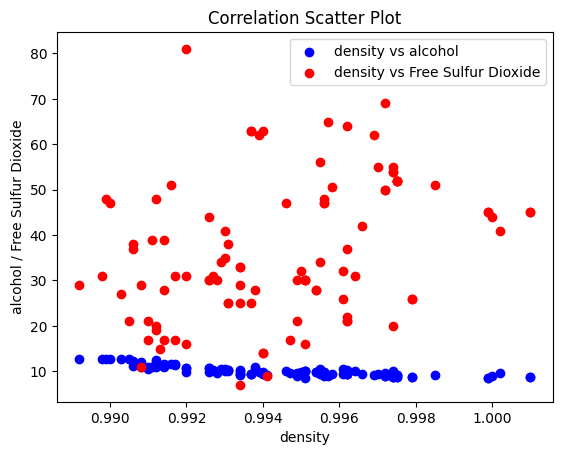

In [38]:
# Scatter plot for alcohol and fixed acidity
plt.scatter(df[variable1_name], df[variable2_name], label=f'{variable1_name} vs {variable2_name}', color='blue')

# Scatter plot for {variable1_name} and free sulfur dioxide
plt.scatter(df[variable1_name], df[variable3_name], label=f'{variable1_name} vs Free Sulfur Dioxide', color='red')

# Titles and labels
plt.title('Correlation Scatter Plot')
plt.xlabel(f'{variable1_name}')
plt.ylabel(f'{variable2_name} / Free Sulfur Dioxide')

# Legend
plt.legend()

# Show the plot
plt.show()

Mean Squared Error: 0.6169371107882714
Linear Regression Equation: y = 6.390 + -8.675 * chlorides


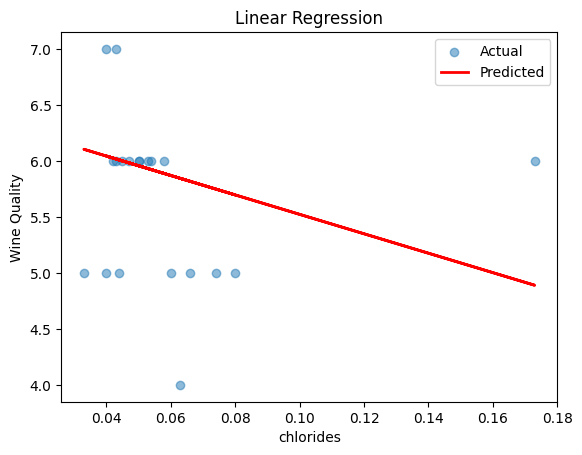

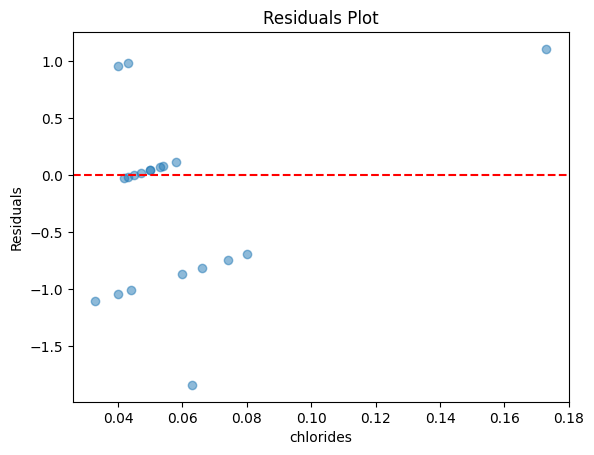

In [57]:
# Assuming df, var_names[index], and 'quality' are defined

# Extracting the feature
var_names = ['residual sugar', 'chlorides', 'total sulfur dioxide', 'density']
def printg(index):
  X = df[[var_names[index]]]
  y = df['quality']

  # Splitting the data into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Creating and fitting the model
  model = LinearRegression()
  model.fit(X_train, y_train)

  # Making predictions on the test set
  predictions = model.predict(X_test)

  # Evaluating the model
  mse = mean_squared_error(y_test, predictions)
  print(f"Mean Squared Error: {mse}")

  # Linear regression equation
  coefficients = model.coef_
  intercept = model.intercept_
  print(f"Linear Regression Equation: y = {intercept:.3f} + {coefficients[0]:.3f} * {var_names[index]}")

  # Plot the regression line
  plt.scatter(X_test[var_names[index]], y_test, alpha=0.5, label='Actual')
  plt.plot(X_test[var_names[index]], predictions, color='red', linewidth=2, label='Predicted')
  plt.title('Linear Regression')
  plt.xlabel(var_names[index])
  plt.ylabel('Wine Quality')
  plt.legend()
  plt.show()

  # Plot residuals
  residuals = y_test - predictions
  plt.scatter(X_test[var_names[index]], residuals, alpha=0.5)
  plt.title('Residuals Plot')
  plt.xlabel(var_names[index])
  plt.ylabel('Residuals')
  plt.axhline(y=0, color='r', linestyle='--')
  plt.show()
printg(1)

In [67]:
# Assuming df, y, variable1_name, variable2_name, variable3_name, variable4_name are defined
y = df['quality']
# Extracting the features
X_multi = df[[variable1_name, variable2_name, variable3_name]]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.3, random_state=42)

# Creating and fitting the model
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Making predictions on the test set
predictions_multi = model_multi.predict(X_test)

# Calculating MSE
mse = mean_squared_error(y_test, predictions_multi)

# Calculating R-squared
r_squared = model_multi.score(X_test, y_test)

# Calculating adjusted R-squared
n = len(y_test)
k = X_test.shape[1]
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)

# Printing the results
print(f"Mean Squared Error: {mse:.3f}")
print(f"R-squared: {r_squared:.3f}")
print(f"Adjusted R-squared: {adjusted_r_squared:.3f}")

# Coefficients and Intercept
coefficients = model_multi.coef_
intercept = model_multi.intercept_
print("Coefficients:", coefficients)
print("Intercept:", intercept)


Mean Squared Error: 0.639
R-squared: -0.208
Adjusted R-squared: -0.348
Coefficients: [-4.44145643e+01  3.56920927e-01 -2.28038065e-04]
Intercept: 46.56973326393389


In [66]:
# means for variable 1, 2 and 3
print(variable1_name)
print(variable2_name)
print(variable3_name)

density
alcohol
free sulfur dioxide
